In [ ]:
import pandas as pd
from factor_analyzer import calculate_kmo
import numpy as np
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity
from scipy.stats import chi2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler



file_path = '/Users/macbook/Downloads/SV/data thuc hanh/pca_practice.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1')

data = df.drop('Code', axis=1)


if data.isnull().sum().any():
    data = data.dropna()

correlation_matrix = data.corr()

det = np.linalg.det(correlation_matrix)
print(f"Determinant of correlation matrix: {det}")

if det <= 0:
    print("Cảnh báo: Ma trận tương quan không khả nghịch, có thể do đa cộng tuyến hoàn hảo.")
else:
 
    kmo_all, kmo_model = calculate_kmo(data)
    
    print(f"KMO Overall: {kmo_model}")
    print("\nKMO cho từng biến:")
    for i, col in enumerate(data.columns):
        print(f"{col}: {kmo_all[i]:.4f}")

    
    if kmo_model >= 0.9:
        print("\nĐánh giá: Tuyệt vời")
    elif kmo_model >= 0.8:
        print("\nĐánh giá: Tốt")
    elif kmo_model >= 0.7:
        print("\nĐánh giá: Trung bình")
    elif kmo_model >= 0.6:
        print("\nĐánh giá: Tạm được")
    else:
        print("\nĐánh giá: Không phù hợp")

Determinant of correlation matrix: 0.11518058755517241
KMO Overall: 0.8331968872810205

KMO cho từng biến:
y1: 0.8495
y2: 0.8182
y3: 0.8359
y4: 0.8740
y5: 0.8250
y6: 0.8350
y7: 0.8320
y8: 0.8266
y9: 0.8228
y10: 0.8667
y11: 0.8230
y12: 0.8204
y13: 0.8309
y14: 0.4309
y15: 0.4287

Đánh giá: Tốt


In [ ]:
chi_square_value, p_value = calculate_bartlett_sphericity(data)

print(f"Chi-square value: {chi_square_value:.4f}")
print(f"p-value: {p_value}")


n_variables = data.shape[1]
df_bartlett = n_variables * (n_variables - 1) // 2
print(f"Bậc tự do: {df_bartlett}")


critical_value = chi2.ppf(0.95, df_bartlett)
print(f"(α=0.05): {critical_value:.4f}")

print(f"Number of values: {n_variables}")
print(f"Observation: {data.shape[0]}")


significant_correlations = (np.abs(correlation_matrix) > 0.3).sum().sum() - n_variables
print(f"Number of significantly correlated pairs (|r| > 0.3): {significant_correlations}")

Chi-square value: 1606.1720
p-value: 6.317922293059546e-267
Bậc tự do: 105
(α=0.05): 129.9180
Number of values: 15
Observation: 750
Number of significantly correlated pairs (|r| > 0.3): 30


In [ ]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

pca = PCA()
pca.fit(data_scaled)

eigenvalues = pca.explained_variance_

print("All eigenvalues:")
for i, eigenvalue in enumerate(eigenvalues, 1):
    print(f"PC{i}: {eigenvalue:.4f}")

explained_variance_ratio = pca.explained_variance_ratio_
print(f"\nPhần trăm phương sai giải thích:")
for i, ratio in enumerate(explained_variance_ratio, 1):
    print(f"PC{i}: {ratio*100:.2f}%")

cumulative_variance = np.cumsum(explained_variance_ratio)
print(f"\nPhần trăm phương sai tích lũy:")
for i, cum_ratio in enumerate(cumulative_variance, 1):
    print(f"Đến PC{i}: {cum_ratio*100:.2f}%")

n_components_kaiser = sum(eigenvalues > 1)
print(f"\nSố thành phần theo tiêu chí Kaiser (eigenvalue > 1): {n_components_kaiser}")

n_components_80 = sum(cumulative_variance <= 0.8) + 1
print(f"Số thành phần giải thích 80% phương sai: {n_components_80}")

plt.figure(figsize=(12, 6))

All eigenvalues:
PC1: 3.5547
PC2: 1.2954
PC3: 1.2055
PC4: 1.1536
PC5: 1.0566
PC6: 0.9653
PC7: 0.7516
PC8: 0.7029
PC9: 0.6853
PC10: 0.6723
PC11: 0.6514
PC12: 0.6162
PC13: 0.5942
PC14: 0.5876
PC15: 0.5274

Phần trăm phương sai giải thích:
PC1: 23.67%
PC2: 8.62%
PC3: 8.03%
PC4: 7.68%
PC5: 7.03%
PC6: 6.43%
PC7: 5.00%
PC8: 4.68%
PC9: 4.56%
PC10: 4.48%
PC11: 4.34%
PC12: 4.10%
PC13: 3.96%
PC14: 3.91%
PC15: 3.51%

Phần trăm phương sai tích lũy:
Đến PC1: 23.67%
Đến PC2: 32.29%
Đến PC3: 40.32%
Đến PC4: 48.00%
Đến PC5: 55.03%
Đến PC6: 61.46%
Đến PC7: 66.46%
Đến PC8: 71.14%
Đến PC9: 75.70%
Đến PC10: 80.18%
Đến PC11: 84.52%
Đến PC12: 88.62%
Đến PC13: 92.58%
Đến PC14: 96.49%
Đến PC15: 100.00%

Số thành phần theo tiêu chí Kaiser (eigenvalue > 1): 5
Số thành phần giải thích 80% phương sai: 10


<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

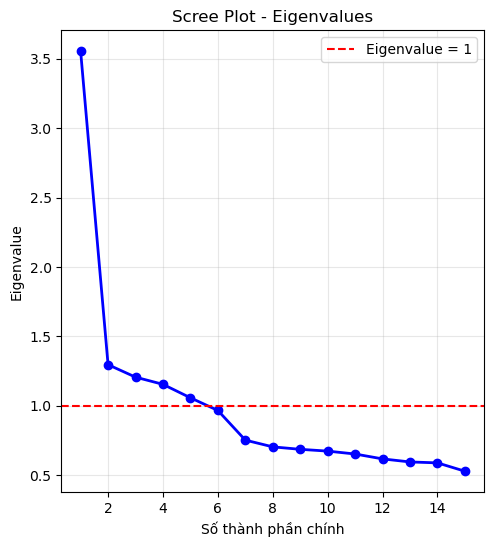

In [ ]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(eigenvalues) + 1), eigenvalues, 'bo-', linewidth=2, markersize=6)
plt.axhline(y=1, color='r', linestyle='--', label='Eigenvalue = 1')
plt.xlabel('Số thành phần chính')
plt.ylabel('Eigenvalue')
plt.title('Scree Plot - Eigenvalues')
plt.legend()
plt.grid(True, alpha=0.3)